---
# Pre-TARE Adoption KPIs: Spark Gap, Thermal COP, Break-Even COP
---

**Author:** Jordan M. Joseph, PhD — Carnegie Mellon University

Computes adoption economics metrics that can be calculated directly from EUSS
data and EIA fuel prices, without requiring a TARE model run.

**Workflow:** Load EUSS data → spark gap → thermal COP & AFUE → break-even COP → maps

**Batch Mode:** Set `input_measure_package` before calling via `%run -i` to skip prompts.

See `README_adoption_kpis.md` for methodology notes and design decisions.

In [12]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import VALID_MENU_MPS, PA_COP_RANGES
from cmu_tare_model.adoption_kpis import (
    load_euss_baseline, load_euss_upgrade, mp_to_upgrade,
    calculate_spark_gap, compute_thermal_cop, compute_breakeven_cop,
)
from cmu_tare_model.adoption_kpis.thermal_cop import COP_BENCHMARK_RANGES
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe, create_choropleth_map,
)
from cmu_tare_model.adoption_kpis.data_loading import FUEL_PRICES_PATH, SHAPEFILE_PATH

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
print("[OK] Imports loaded")
print(f"Project root: {PROJECT_ROOT}")


[OK] Imports loaded
Project root: c:\users\jorda\desktop\projects\cmu-tare-model


In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"\nSelected measure packages: {selected_mps}")

Available measure packages: [3, 4]

Selected measure packages: [3, 4]


In [3]:
print("=" * 80)
print("STEP 1: LOAD EUSS DATA")
print("=" * 80)

df_baseline = load_euss_baseline()
print(f"  Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n[OK] STEP 1 COMPLETE")

STEP 1: LOAD EUSS DATA
Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:176: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
  Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:210: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:210: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP4: 331,526 applicable homes

[OK] STEP 1 COMPLETE


---
## Step 2: Fuel Price Ratios (Spark Gap)
---

In [4]:
print("=" * 60)
print("STEP 2: SPARK GAP (2024 EIA nominal prices)")
print("=" * 60)

df_spark_gap = calculate_spark_gap(FUEL_PRICES_PATH, year=2024)
print(f"[OK] {len(df_spark_gap)} states loaded")
print(f"  Mean: {df_spark_gap['spark_gap'].mean():.2f}, "
      f"Range: {df_spark_gap['spark_gap'].min():.2f}"
      f"–{df_spark_gap['spark_gap'].max():.2f}")
fl = float(df_spark_gap[df_spark_gap['state'] == 'FL']['spark_gap'].values[0])
ak = float(df_spark_gap[df_spark_gap['state'] == 'AK']['spark_gap'].values[0])
print(f"  FL: {fl:.2f}, AK: {ak:.2f}")
print("[OK] STEP 2 COMPLETE")


STEP 2: SPARK GAP (2024 EIA nominal prices)
[OK] 51 states loaded
  Mean: 3.54, Range: 1.69–6.42
  FL: 1.69, AK: 6.42
[OK] STEP 2 COMPLETE


---
## Step 3: Thermal COP and Baseline AFUE
---

In [5]:
print("=" * 60)
print("STEP 3: THERMAL COP (Natural Gas homes)")
print("=" * 60)

cop_results = {}
for mp in selected_mps:
    print(f"\nMP{mp}:")
    cop_results[mp] = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        fuel_filter='Natural Gas', verbose=True,
    )
    print(f"  Mean COP: {cop_results[mp]['thermal_cop'].mean():.3f}")

primary_mp = selected_mps[0]
df_cop = cop_results[primary_mp]
print(f"\n[OK] STEP 3 COMPLETE — Primary MP: {primary_mp}")


STEP 3: THERMAL COP (Natural Gas homes)

MP3:
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state) ---
Groups: 49
Mean:   2.21
Median: 2.20
Range:  1.53 - 3.05
[OK] All groups within COP range [1.5, 5.0]

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.75 - 0.82

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.8%
Range:  1.7% - 5.8%
  Mean COP: 2.213

MP4:
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state) ---
Groups: 49
Mean:   3.89
Median: 3.98
Range:  2.15 - 5.72
[WARN] 8 group(s) with COP outside [1.5, 5.0]:
    AL: 5.06
    CA: 5.72
    FL: 5.70
    GA: 5.06
    LA: 5.35
    MS: 5.02
    SC: 5.06
    TX: 5.30

--- Baseli

---
### Climate Zone Benchmark Validation
---

Aggregates thermal COP by IECC climate zone group and validates against
literature-derived benchmark ranges (`COP_BENCHMARK_RANGES`). Also
produces a state × climate zone cross-tab with a PA spot check.

In [13]:
print("=" * 60)
print("CLIMATE ZONE BENCHMARK VALIDATION")
print("=" * 60)

for mp in selected_mps:
    mp_key = f'mp{mp}'
    print(f"\n--- MP{mp} Climate Zone Group Aggregation ---")

    df_cop_cz = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['cz_group'],
        fuel_filter='Natural Gas',
        verbose=True,
    )

    df_cop_state_cz = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['state', 'cz_group'],
        fuel_filter='Natural Gas',
        verbose=False,
    )

    print(f"\n--- Benchmark Validation (MP{mp}) ---")
    print(f"{'CZ Group':<10} {'Label':<18} {'COP':>6} {'Expected':>14} {'Pass':>6}")
    print("-" * 58)
    n_checked = 0
    n_passed = 0
    for cz_grp, bench in COP_BENCHMARK_RANGES.items():
        row = df_cop_cz[df_cop_cz['cz_group'] == cz_grp]
        if len(row) == 0:
            print(f"{cz_grp:<10} {bench['label']:<18} {'N/A':>6} {'':<14} {'SKIP':>6}")
            continue
        cop_val = row['thermal_cop'].values[0]
        if mp_key in bench:
            lo, hi = bench[mp_key]
            in_range = lo <= cop_val <= hi
            n_checked += 1
            n_passed += int(in_range)
            range_str = f"[{lo:.1f}, {hi:.1f}]"
            print(f"{cz_grp:<10} {bench['label']:<18} {cop_val:>6.2f} {range_str:>14} "
                  f"{'[OK]' if in_range else '[FAIL]':>6}")
        else:
            print(f"{cz_grp:<10} {bench['label']:<18} {cop_val:>6.2f} {'no bench':>14} {'—':>6}")
    print(f"\nOverall: {n_passed}/{n_checked} climate zone groups within expected range")

    pa_rows = df_cop_state_cz[df_cop_state_cz['state'] == 'PA']
    if len(pa_rows) > 0:
        print(f"\n--- PA Spot Check (MP{mp}) ---")
        for _, pa_row in pa_rows.iterrows():
            cop_val = pa_row['thermal_cop']
            cz = pa_row['cz_group']
            if mp_key in PA_COP_RANGES:
                lo, hi = PA_COP_RANGES[mp_key]
                ok = lo <= cop_val <= hi
                print(f"  PA (CZ {cz}): COP = {cop_val:.2f}, "
                      f"expected [{lo:.1f}, {hi:.1f}] -> {'[OK] PASS' if ok else '[FAIL] FAIL'}")
            else:
                print(f"  PA (CZ {cz}): COP = {cop_val:.2f} (no PA benchmark for {mp_key})")
    else:
        print("\n[WARN] PA not found in state x CZ cross-tab")

print(f"\n[OK] VALIDATION COMPLETE")


CLIMATE ZONE BENCHMARK VALIDATION

--- MP3 Climate Zone Group Aggregation ---
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by cz_group) ---
Groups: 3
Mean:   2.15
Median: 2.05
Range:  1.67 - 2.74
[OK] All groups within COP range [1.5, 5.0]

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.80 - 0.81

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.4%
Range:  2.2% - 4.8%

--- Benchmark Validation (MP3) ---
CZ Group   Label                 COP       Expected   Pass
----------------------------------------------------------
1-3        Warm (CZ 1-3)        2.74     [2.4, 3.2]   [OK]
4-5        Mixed (CZ 4-5)       2.05     [2.0, 2.8]   [OK]
6-7        Cold (CZ 6-7)        1.67     [1.6, 2.4]   [OK]

Overall: 3/3 climate zone groups within expected range

--- PA Spot Check (MP3) ---
  PA (CZ 

---
## Step 4: Break-Even COP and Merged Metrics
---

In [7]:
from cmu_tare_model.constants import JENKINS_BREAKEVEN_REF_90

print("=" * 60)
print("STEP 4: BREAK-EVEN COP")
print("=" * 60)

df_breakeven = compute_breakeven_cop(df_spark_gap, df_cop)
be90 = df_breakeven['breakeven_cop_90']
print(f"[OK] BE @90% AFUE — Mean: {be90.mean():.2f}, "
      f"Range: {be90.min():.2f}–{be90.max():.2f}")

n_pass, n_total = 0, len(JENKINS_BREAKEVEN_REF_90)
for st, ref in JENKINS_BREAKEVEN_REF_90.items():
    row = df_breakeven[df_breakeven['state'] == st]
    if len(row) > 0 and abs(float(row['breakeven_cop_90'].values[0]) - ref) <= 0.50:
        n_pass += 1
print(f"Jenkins validation (+-0.50): {n_pass}/{n_total} states")
print("[OK] STEP 4 COMPLETE")


STEP 4: BREAK-EVEN COP
[OK] BE @90% AFUE — Mean: 3.15, Range: 1.52–4.90
Jenkins validation (+-0.50): 5/6 states
[OK] STEP 4 COMPLETE


---
## Step 5: Geospatial Visualization
---

In [8]:
gdf_conus = None
gdf_alaska = None

# Merge all state-level metrics for map rendering
df_map = df_spark_gap.merge(
    df_cop[['state', 'thermal_cop', 'baseline_afue']], on='state', how='inner'
).merge(
    df_breakeven[['state', 'breakeven_cop_90']], on='state', how='inner'
)

try:
    print(f"Loading shapefile from: {SHAPEFILE_PATH}")
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    _, gdf_conus, gdf_alaska = prepare_state_geodataframe(
        gdf_states_raw, df_map, merge_col='state'
    )
    print(f"  CONUS: {len(gdf_conus)}, Alaska: {len(gdf_alaska)}")
    print("[OK] Geodataframe prepared")
except FileNotFoundError:
    print(f"[WARN] Shapefile not found at {SHAPEFILE_PATH} — skipping maps")
except Exception as e:
    print(f"[WARN] Could not load shapefile: {e}")


Loading shapefile from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\electricity_ng_price_ratio\nhgis0011_shapefile_tl2015_us_state_2015\US_state_2015.shp
  CONUS: 49, Alaska: 0
[OK] Geodataframe prepared


Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_spark_gap_map_2024.png


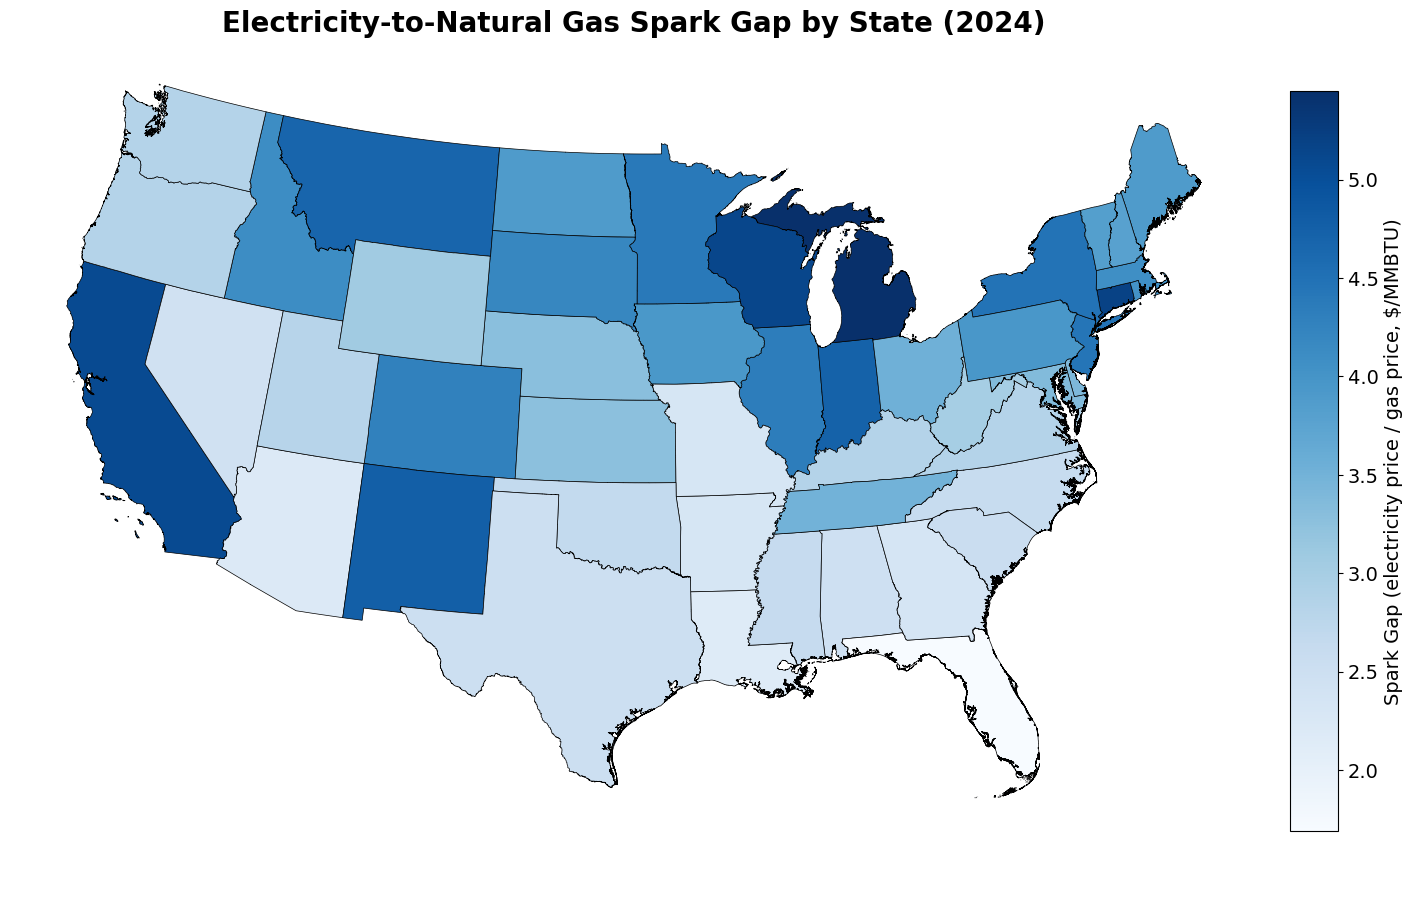

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_thermal_cop_mp3_map_2024.png


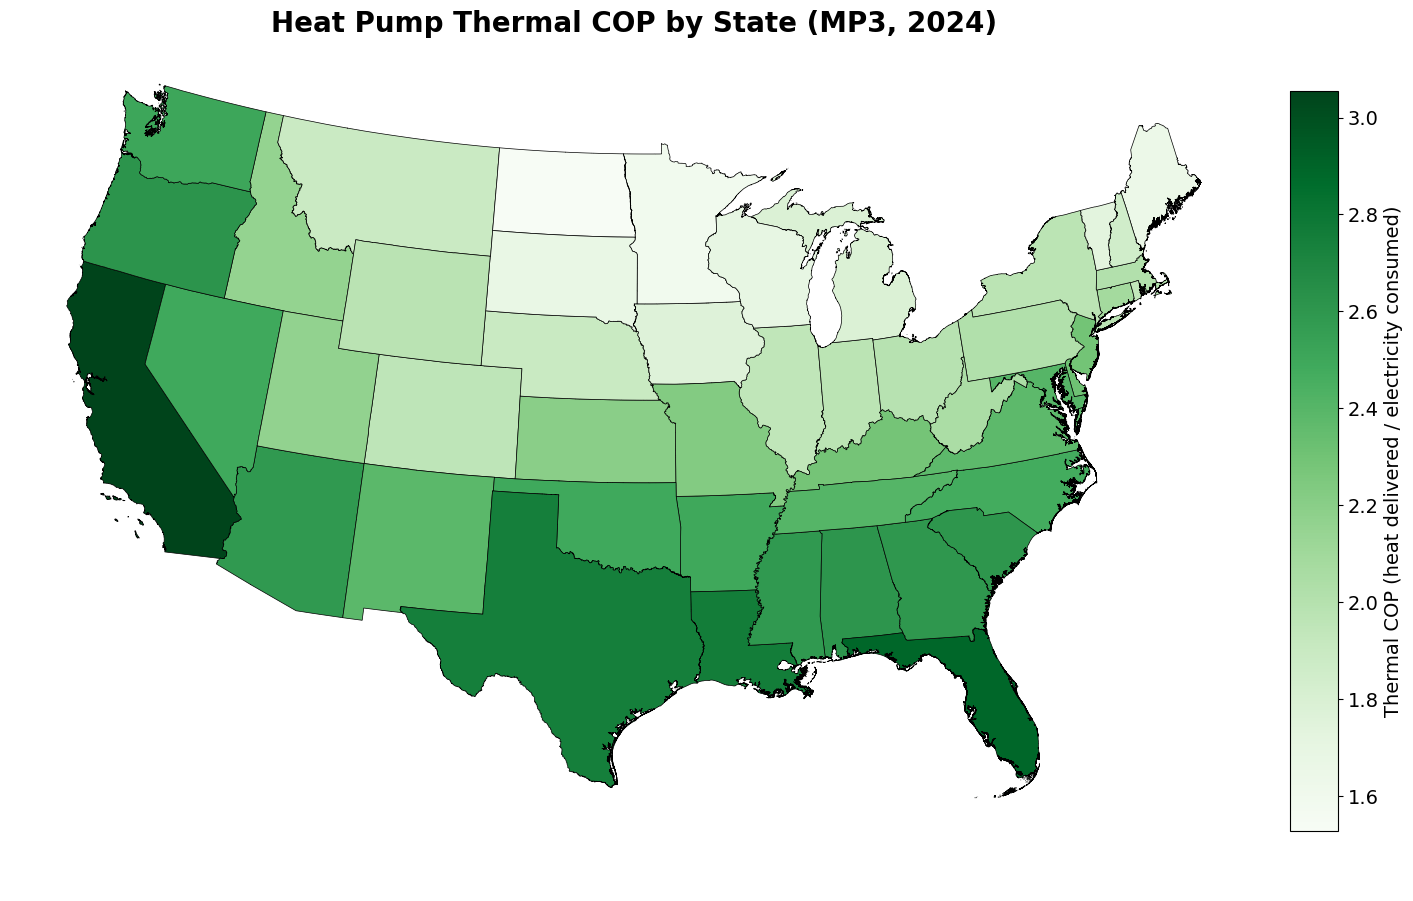

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_breakeven_cop_90_map_2024.png


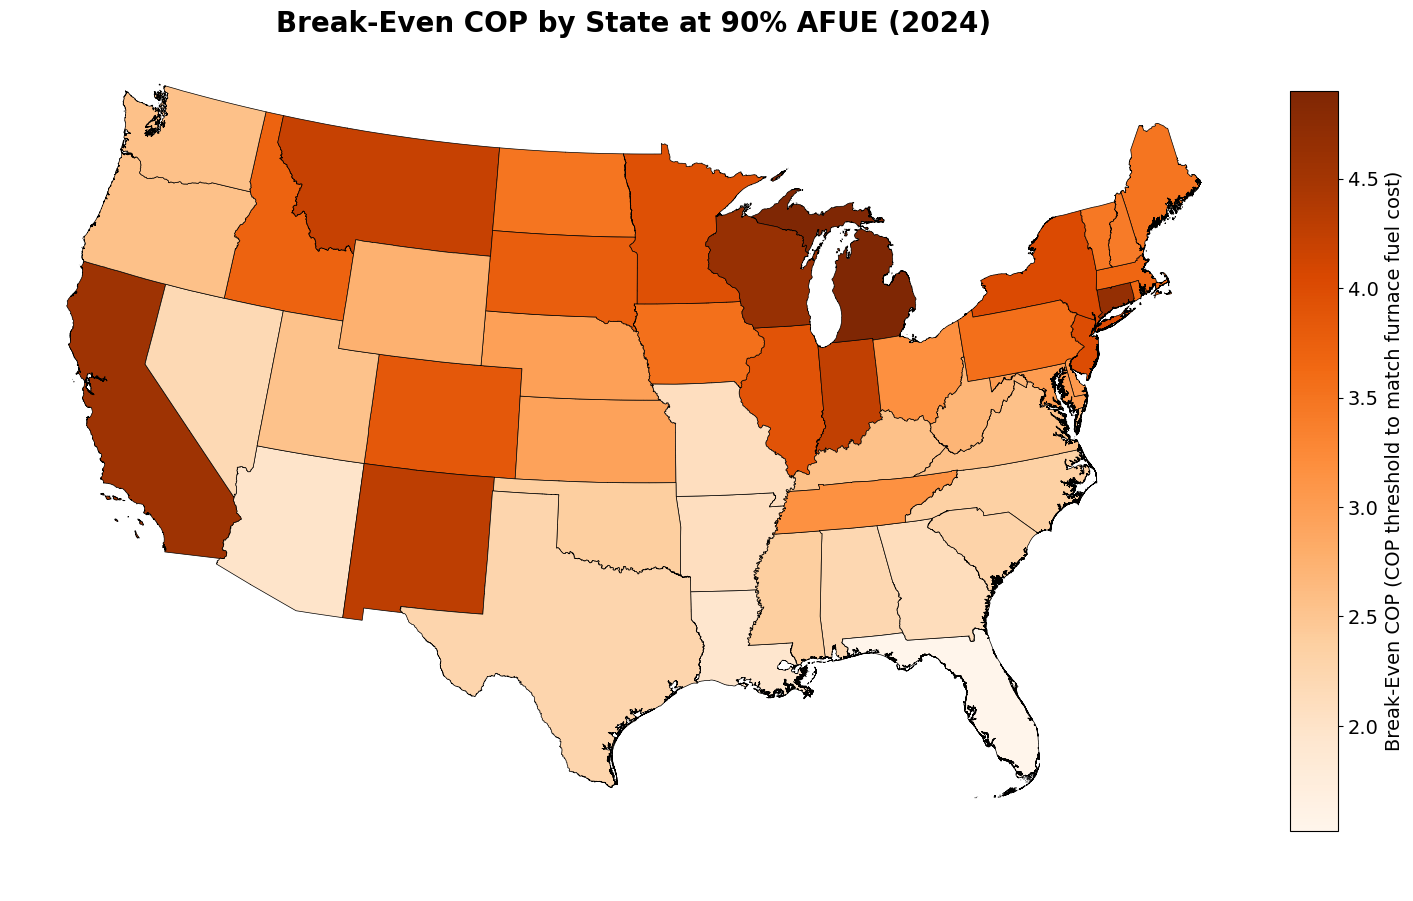

[OK] Maps generated


In [9]:
if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")
    for column, title, cmap, cbar, fname in [
        ('spark_gap',
         'Electricity-to-Natural Gas Spark Gap by State (2024)',
         'Blues', 'Spark Gap (electricity price / gas price, $/MMBTU)',
         'state_spark_gap_map_2024.png'),
        ('thermal_cop',
         f'Heat Pump Thermal COP by State (MP{primary_mp}, 2024)',
         'Greens', 'Thermal COP (heat delivered / electricity consumed)',
         f'state_thermal_cop_mp{primary_mp}_map_2024.png'),
        ('breakeven_cop_90',
         'Break-Even COP by State at 90% AFUE (2024)',
         'Oranges', 'Break-Even COP (COP threshold to match furnace fuel cost)',
         'state_breakeven_cop_90_map_2024.png'),
    ]:
        create_choropleth_map(
            gdf_conus, gdf_alaska, column=column, title=title,
            cbar_label=cbar, cmap=cmap, show_plot=True, dpi=600,
            output_path=os.path.join(PROJECT_ROOT, fname),
        )
    print("[OK] Maps generated")
else:
    print("[WARN] Maps skipped — no geodataframe available")


In [14]:
print("===== SPARK GAP (2024 nominal) =====\n")
print(df_spark_gap[['state', 'state_name', 'spark_gap',
                     'elec_price_mmbtu', 'gas_price_mmbtu']].to_string())

for mp in selected_mps:
    print(f"\n===== THERMAL COP & AFUE (MP{mp}, NG homes) =====\n")
    print(cop_results[mp].sort_values('thermal_cop', ascending=False)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ].to_string())

# --- Comparison table: spark gap, break-even COP, effective COP ---
print(f"\n===== SPARK GAP & BREAK-EVEN COP vs EFFECTIVE COP (MP{primary_mp}) =====\n")

df_display = df_breakeven.copy()
df_display['thermal_cop'] = (
    df_cop.set_index('state')['thermal_cop']
    .reindex(df_display['state'].values)
    .values
)
df_display['hp_beats_breakeven_90'] = (
    df_display['thermal_cop'] > df_display['breakeven_cop_90']
)

print(df_display[[
    'state', 'state_name', 'spark_gap',
    'breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95', 'breakeven_cop_100',
    'thermal_cop', 'baseline_afue', 'hp_beats_breakeven_90',
]].sort_values('spark_gap', ascending=False).reset_index(drop=True).to_string())


===== SPARK GAP (2024 nominal) =====

   state            state_name  spark_gap  elec_price_mmbtu  gas_price_mmbtu
0     AK                Alaska       6.42             72.74            11.32
1     MI              Michigan       5.45             56.56            10.39
2     CT           Connecticut       5.19             84.26            16.24
3     WI             Wisconsin       5.14             50.35             9.79
4     CA            California       5.07             93.69            18.47
5     NM            New Mexico       4.76             41.62             8.74
6     IN               Indiana       4.72             43.29             9.17
7     MT               Montana       4.68             37.10             7.93
8     NY              New York       4.47             71.60            16.00
9     NJ            New Jersey       4.45             56.68            12.75
10    MN             Minnesota       4.40             45.28            10.28
11    IL              Illinois       4